In [36]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
%matplotlib inline

import inversion_tools

#aus_start_date = '2015-10-01'
aus_start_date = '2014-10-01'
aus_emis_date = '2016-05-01'
aus_end_date   = '2018-05-01'
sibr_start_date = '2019-10-01'
sibr_emis_date = '2020-06-01'
sibr_end_date   = '2023-06-01'
pdir  = '/work/noaa/co2/jhollo/processed_transport_data/'

lat_avg  = lambda data: data.weighted(np.cos(np.deg2rad(data.lat))).mean('lat')
lon_avg  = lambda data: data.mean('lon')
horz_avg = lambda data: lon_avg(lat_avg(data))

In [2]:
# ------------ read control emissions data for Australia gpp
if(0):
    args  = {'start_date':aus_start_date, 'end_date':aus_end_date, 'processing_dir':pdir, 'return_mf':False, 'quiet':True}
    aus_gpp_flx_pft6 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=6)
    aus_gpp_flx_pft9 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=9)
    aus_gpp_flx_pft10 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=10)
# ------------ read control emissions data for Siberia gpp
if(0):
    args  = {'start_date':sibr_start_date, 'end_date':sibr_end_date, 'processing_dir':pdir, 'return_mf':False, 'quiet':True}
    sibr_gpp_flx_pft7 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=7)
    sibr_gpp_flx_pft8 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=8)
    sibr_gpp_flx_pft9 = inversion_tools.read_transport_jacobians_control('gpp', **args, pft=9)

In [3]:
# ------------ read residual emissions data for gpp from Australia, pfts 6, 9, 10
if(0):
    args  = {'start_date':aus_emis_date, 'end_date':aus_end_date, 'month':aus_emis_date.strip('-01'), 'processing_dir':pdir, 'return_flux':False, 'quiet':True}
    aus_gpp_mf_pft6 = inversion_tools.read_transport_jacobians_residual('gpp', region=10, pft=6, **args)
    aus_gpp_mf_pft9 = inversion_tools.read_transport_jacobians_residual('gpp', region=10, pft=9, **args)
    aus_gpp_mf_pft10 = inversion_tools.read_transport_jacobians_residual('gpp', region=10, pft=10, **args)
# ------------ read residual emissions data for gpp from Siberia, pfts 7,8,9
if(0):
    args  = {'start_date':sibr_emis_date, 'end_date':sibr_end_date, 'month':sibr_emis_date.strip('-01'), 'processing_dir':pdir, 'return_flux':False, 'quiet':True}
    sibr_gpp_mf_pft7 = inversion_tools.read_transport_jacobians_residual('gpp', region=7, pft=7, **args)
    sibr_gpp_mf_pft8 = inversion_tools.read_transport_jacobians_residual('gpp', region=7, pft=8, **args)
    sibr_gpp_mf_pft9 = inversion_tools.read_transport_jacobians_residual('gpp', region=7, pft=9, **args)

In [4]:

# ---------- get net gpp for pfts ----------
save_dir = '/work/noaa/co2/jhollo/processed_transport_data/pft_residual_sums'
try:
    aus_fname = f'{save_dir}/aus_gpp_mf_pft6-9-10_{aus_emis_date}_{aus_end_date}.nc'
    sibr_fname = f'{save_dir}/sibr_gpp_mf_pft6-9-10_{sibr_emis_date}_{sibr_end_date}.nc'
    aus_gpp_mf_res = xr.open_dataset(aus_fname)['residual']
    print('read aus from file..')
except FileNotFoundError:
    print('computing for aus...')
    aus_gpp_mf_res = aus_gpp_mf_pft6['residual'] + aus_gpp_mf_pft9['residual'] + aus_gpp_mf_pft10['residual']
    aus_gpp_mf_res.to_netcdf(aus_fname)
try:
    sibr_gpp_mf_res = xr.open_dataset(sibr_fname)['residual']
    print('read sibr from file..')
except FileNotFoundError:
    print('computing for sibr...')
    sibr_gpp_mf_res = sibr_gpp_mf_pft7['residual'] + sibr_gpp_mf_pft8['residual'] + sibr_gpp_mf_pft9['residual']
    sibr_gpp_mf_res.to_netcdf(sibr_fname)

# ---------- get zonal means ----------
try:
    aus_fname  = f'{save_dir}/aus_gpp_mf_pft6-9-10_{aus_emis_date}_{aus_end_date}_zm.nc'
    aus_gpp_mf_res_zm  = xr.open_dataset(aus_fname)['residual']
    print('read aus zm from file..')
except FileNotFoundError:
    print('comptuing aus zonal mean..')
    aus_gpp_mf_res_zm = aus_gpp_mf_res.mean('lon')
    aus_gpp_mf_res_zm.to_netcdf(aus_fname)
try:
    sibr_fname = f'{save_dir}/sibr_gpp_mf_pft6-9-10_{sibr_emis_date}_{sibr_end_date}_zm.nc'
    sibr_gpp_mf_res_zm = xr.open_dataset(sibr_fname)['residual']
    print('read sibr zm from file..')
except FileNotFoundError:
    print('comptuing sibr zonal mean..')
    sibr_gpp_mf_res_zm = sibr_gpp_mf_res.mean('lon')
    sibr_gpp_mf_res_zm.to_netcdf(sibr_fname)

# ---------- get column averages ----------
try:
    aus_fname  = f'{save_dir}/aus_gpp_mf_pft6-9-10_{aus_emis_date}_{aus_end_date}_X.nc'
    aus_gpp_mf_res_X  = xr.open_dataset(aus_fname)['residual_column_average']
    print('read aus X from file..')
except FileNotFoundError:
    print('comptuing aus column average..')
    aus_gpp_mf_res_X = inversion_tools.column_average(aus_gpp_mf_res, outfile=aus_fname)
try:
    sibr_fname = f'{save_dir}/sibr_gpp_mf_pft6-9-10_{sibr_emis_date}_{sibr_end_date}_X.nc'
    sibr_gpp_mf_res_X = xr.open_dataset(sibr_fname)['residual_column_average']
    print('read sibr zm from file..')
except FileNotFoundError:
    print('comptuing sibr column average..')
    sibr_gpp_mf_res_X = inversion_tools.column_average(sibr_gpp_mf_res, outfile=sibr_fname)

# ---------- get column center of mass ----------
overwrite=False
try:
    aus_fname  = f'{save_dir}/aus_gpp_mf_pft6-9-10_{aus_emis_date}_{aus_end_date}_COM.nc'
    if(overwrite): raise FileNotFoundError
    aus_gpp_mf_res_COM  = xr.open_dataset(aus_fname)['residual_vertical_com']
    print('read aus COM from file..')
except FileNotFoundError:
    print('comptuing aus column COM..')
    aus_gpp_mf_res_COM = inversion_tools.column_center_of_mass(aus_gpp_mf_res_zm, outfile=aus_fname, overwrite=overwrite)
try:
    sibr_fname = f'{save_dir}/sibr_gpp_mf_pft6-9-10_{sibr_emis_date}_{sibr_end_date}_COM.nc'
    if(overwrite): raise FileNotFoundError
    sibr_gpp_mf_res_COM = xr.open_dataset(sibr_fname)['residual_vertical_com']
    print('read sibr zm from file..')
except FileNotFoundError:
    print('comptuing sibr column COM..')
    sibr_gpp_mf_res_COM = inversion_tools.column_center_of_mass(sibr_gpp_mf_res_zm, outfile=sibr_fname, overwrite=overwrite)

print('done')

read aus from file..
read sibr from file..
read aus zm from file..
read sibr zm from file..
read aus X from file..
read sibr zm from file..
read aus COM from file..
read sibr zm from file..
done


In [5]:
# ------------ plot zonal-mean time series for mf at select pressure levels

if(0):
    # ---- Australia gpp
    plev = 35
    dd = aus_gpp_mf_res_zm.isel(lev=plev).isel(time=slice(0, 900))
    levels = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
    fig = plt.figure()
    ax = fig.add_subplot()
    cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=10, extend='both', cmap='YlGn_r')
    ax.contour(dd.lat, dd.time, dd*1e3, levels=10, colors='k', linestyles='-', linewidths=0.2)
    ax.set_xlabel('latitude')
    ax.set_ylim(np.datetime64(aus_emis_date), np.datetime64(aus_emis_date)+np.timedelta64(365, 'D'))
    cb = plt.colorbar(cf, location='top')
    cb.set_label(f'{inversion_tools.lev_to_p(plev)} hPa mole fraction response to Australia gpp residual flux [ppb]')
    plt.savefig('Aus_gpp_lat_time_100hPa.png', dpi=200)
if(0):
    # ---- Siberia gpp
    plev = 25
    dd = sibr_gpp_mf_res_zm.isel(lev=plev).isel(time=slice(0, 900))
    levels = [-20, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
    #levels = [-10, -3.3, -1, -0.33, -0.1, 0]
    levels = np.arange(-250, 1, 25)
    fig = plt.figure()
    ax = fig.add_subplot()
    cf = ax.contourf(dd.lat, dd.time, dd*1e3, levels=levels, extend='both', cmap='YlGn_r')
    ax.contour(dd.lat, dd.time, dd*1e3, levels=levels, colors='k', linestyles='-', linewidths=0.2)
    ax.set_xlabel('latitude')
    ax.set_ylim(np.datetime64(sibr_emis_date), np.datetime64(sibr_emis_date)+np.timedelta64(365, 'D'))
    cb = plt.colorbar(cf, location='top')
    cb.set_label(f'{inversion_tools.lev_to_p(plev)} hPa mole fraction response to Siberia gpp residual flux [ppb]')
    plt.savefig('Sibr_gpp_lat_time_100hPa.png', dpi=200)

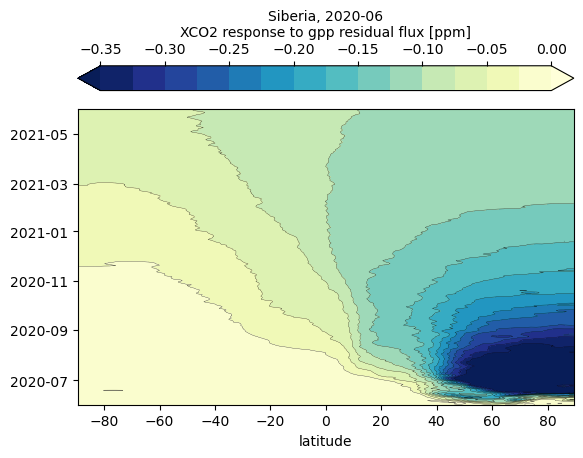

In [55]:
# ---- Siberia gpp
dd = sibr_gpp_mf_res_X.mean('lon').isel(time=slice(0, 900))
levels = [-20, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0]
#levels = [-10, -3.3, -1, -0.33, -0.1, 0]
levels = np.arange(-350, 1, 25)/1000
fig = plt.figure()
ax = fig.add_subplot()
cf = ax.contourf(dd.lat, dd.time, dd, levels=levels, extend='both', cmap='YlGnBu_r')
ax.contour(dd.lat, dd.time, dd, levels=levels, colors='k', linestyles='-', linewidths=0.2)
ax.set_xlabel('latitude')
ax.set_ylim(np.datetime64(sibr_emis_date), np.datetime64(sibr_emis_date)+np.timedelta64(365, 'D'))
cb = plt.colorbar(cf, location='top')
cb.set_label(f'Siberia, {sibr_emis_date.strip('-01')}\nXCO2 response to gpp residual flux [ppm]')
plt.savefig('sibr_gpp_lat_time_XCO2.png', dpi=200)

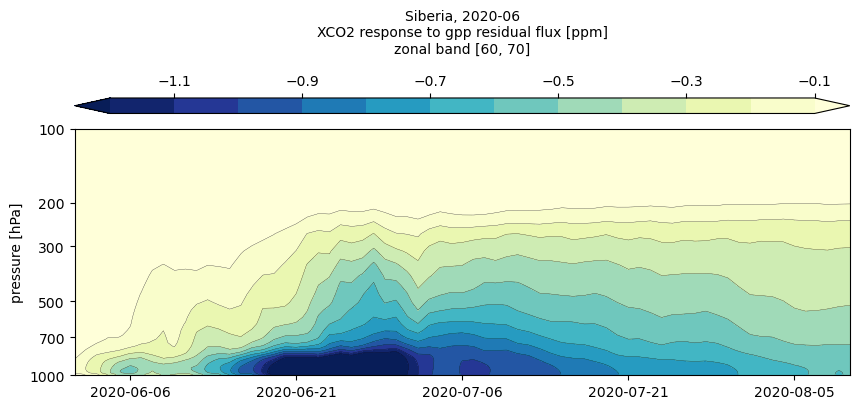

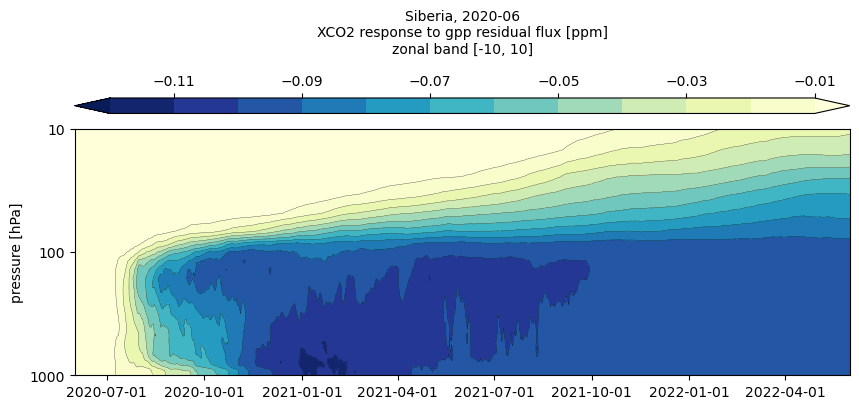

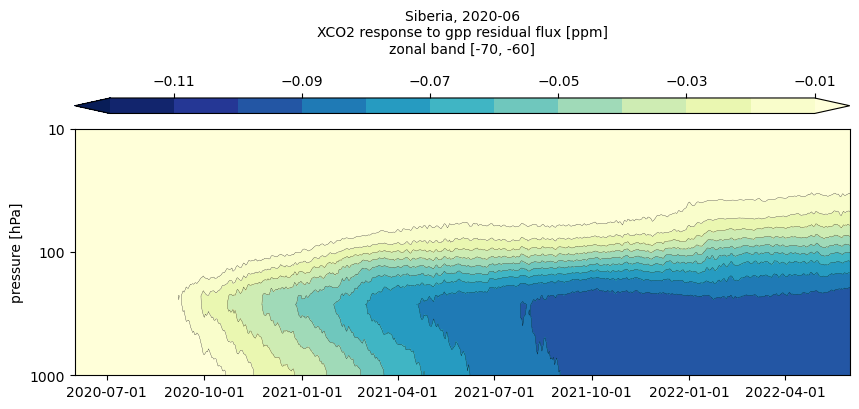

In [56]:
def plot_time_lev(latmin, latmax, pmin, pmax, levels, ndays, filename, ptick=None, daytick=None):

    dd = lat_avg(sibr_gpp_mf_res_zm.sel(lat=slice(latmin, latmax))).T
    
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot()
    cf = ax.contourf(dd.time, dd.lev*1000, dd, levels=levels, extend='both', cmap='YlGnBu_r')
    ax.contour(dd.time, dd.lev*1000, dd, levels=levels, colors='k', linestyles='-', linewidths=0.2)

    ax.set_xlim(np.datetime64(sibr_emis_date), np.datetime64(sibr_emis_date)+np.timedelta64(ndays, 'D'))
    ax.set_ylim([pmin, pmax])
    
    ax.set_ylabel('pressure [hPa]')
    ax.invert_yaxis()
    ax.set_yscale('log')

    cb = plt.colorbar(cf, location='top', aspect=50)
    cb.set_label(f'Siberia, {sibr_emis_date.strip('-01')}\nXCO2 response to gpp residual flux [ppm]\nzonal band [{latmin}, {latmax}]\n')

    if(daytick is not None):
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=daytick))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_minor_locator(ticker.NullLocator())
    if(ptick is not None):
        ax.yaxis.set_ticks(ptick)
        
    plt.savefig(filename, dpi=200)


# ---- time-lev near emission latitude of 6-70 deg
latmin, latmax = 60, 70
pmin, pmax = 100, 1000
levels = np.arange(-120, -1, 10)/100
ptick = [1000, 700, 500, 300, 200, 100]
daytick=15
ndays = 70
fname = 'sibr_gpp_time_lev_emission.png'
plot_time_lev(latmin, latmax, pmin, pmax, levels, ndays, fname, ptick, daytick)

# ---- time-lev in the tropics
latmin, latmax = -10, 10
pmin, pmax = 10, 1000
levels = np.arange(-120, -1, 10)/1000
ndays = 365*2
fname = 'sibr_gpp_time_lev_tropics.png'
plot_time_lev(latmin, latmax, pmin, pmax, levels, ndays, fname)

# ---- time-lev at high latitude band
latmin, latmax = -70, -60
pmin, pmax = 10, 1000
levels = np.arange(-120, -1, 10)/1000
ndays = 365*2
fname = 'sibr_gpp_time_lev_hilat.png'
plot_time_lev(latmin, latmax, pmin, pmax, levels, ndays, fname)

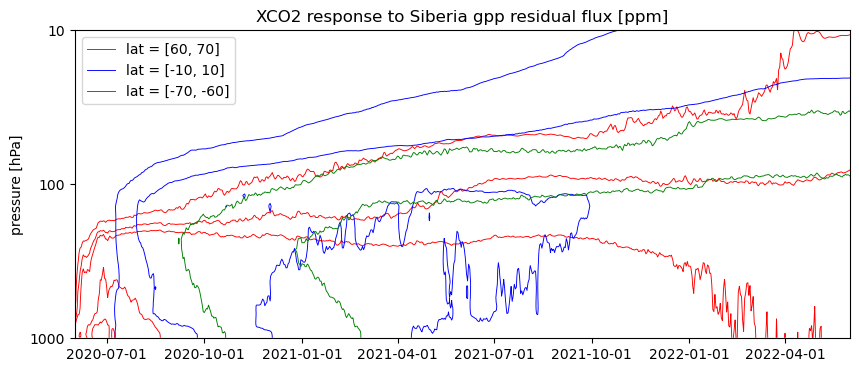

In [8]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot()

def plot_time_lev(latmin, latmax, levels, color):
    dd = lat_avg(sibr_gpp_mf_res_zm.sel(lat=slice(latmin, latmax))).T
    cf = ax.contour(dd.time, dd.lev*1000, dd, levels=levels, colors=color, linestyles='-', linewidths=0.66)
    ax.plot([dd.time.values[0], dd.time.values[0]], [100,100], color=color, lw=0.66, label=f'lat = [{latmin}, {latmax}]')
    return cf

levels = [-1, -0.5, -0.1, -0.05, -0.01]
latmin, latmax = 60, 70
cf = plot_time_lev(latmin, latmax, levels, 'r')
latmin, latmax = -10, 10
plot_time_lev(latmin, latmax, levels, 'b')
latmin, latmax = -70, -60
plot_time_lev(latmin, latmax, levels, 'g')

ax.set_xlim(np.datetime64(sibr_emis_date), np.datetime64(sibr_emis_date)+np.timedelta64(ndays, 'D'))
ax.set_ylim([pmin, pmax])

ax.set_ylabel('pressure [hPa]')
ax.invert_yaxis()
ax.set_yscale('log')

ax.set_title(f'XCO2 response to Siberia gpp residual flux [ppm]')

ax.legend(loc='upper left')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())

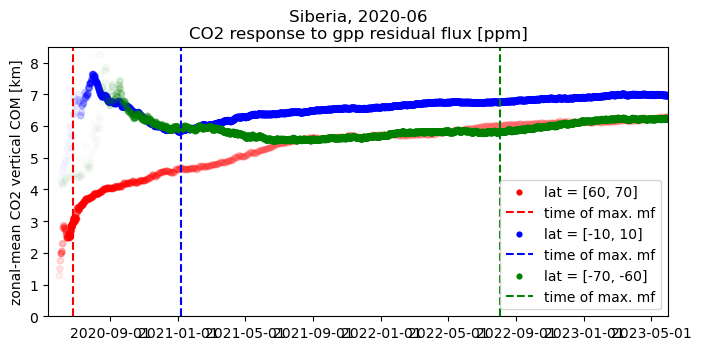

In [54]:
fig = plt.figure(figsize=(8, 3.5))
ax = fig.add_subplot()

norm_mf = sibr_gpp_mf_res_zm / abs(sibr_gpp_mf_res_zm).max(('lev','time'))

def plot_time_lev(latmin, latmax, color):
    dd = lat_avg(sibr_gpp_mf_res_COM.sel(lat=slice(latmin, latmax))).T

    ddz     = lat_avg(sibr_gpp_mf_res_zm.sel(lat=slice(latmin, latmax)))
    norm_mf = abs(ddz).max('lev') / abs(ddz).max(('lev','time'))
    norm_mf = abs(norm_mf)
    peak_time = norm_mf.idxmax('time')
    
    cf = ax.scatter(dd.time, dd, color=color, s=20, alpha=norm_mf,
                    linestyle='-', linewidth=1)
    ax.scatter(dd.time[0], -1, color=color, s=20,
               linestyle='-', linewidth=0, label=f'lat = [{latmin}, {latmax}]')
    ax.axvline(x=peak_time.values, color=color, linestyle='--', label='time of max. mf')
    return cf

levels = [-1, -0.5, -0.1, -0.05, -0.01]
latmin, latmax = 60, 70
cf = plot_time_lev(latmin, latmax, 'r')
latmin, latmax = -10, 10
plot_time_lev(latmin, latmax, 'b')
latmin, latmax = -70, -60
plot_time_lev(latmin, latmax, 'g')

ax.set_title(f'Siberia, {sibr_emis_date.strip('-01')}\nCO2 response to gpp residual flux [ppm]')

ax.legend(loc='lower right')

ndays=365*3
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlim(np.datetime64(sibr_emis_date)-np.timedelta64(20, 'D'), 
            np.datetime64(sibr_emis_date)+np.timedelta64(ndays, 'D'))

ax.set_ylim([0, 8.5])
ax.set_ylabel('zonal-mean CO2 vertical COM [km]')

plt.savefig(f'sibr_gpp_time_COM_{ndays}.png', dpi=200)

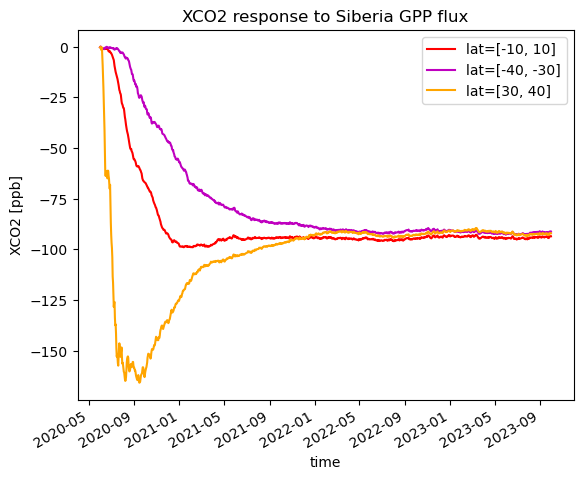

In [57]:
# ------------ plot zonal-mean time series for mf at select pressure levels, and select latitudes

def plot_curves(time, data_trop, data_s, data_n, label):
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.plot(time, data_trop*1e3, '-r', label='lat=[-10, 10]')
    ax.plot(time, data_s*1e3, '-m', label='lat=[-40, -30]')
    ax.plot(time, data_n*1e3, '-', color='orange', label='lat=[30, 40]')
    ax.set_xlabel('time')
    ax.set_ylabel('XCO2 [ppb]')
    ax.set_title(f'{label} response to Siberia GPP flux')
    ax.legend()
    for label in ax.get_xmajorticklabels() + ax.get_xmajorticklabels():
        label.set_rotation(30)
        label.set_horizontalalignment("right")

dd        = sibr_gpp_mf_res_X
dd_trop   = horz_avg(dd.sel(lat=slice(-10, 10)))
dd_s = horz_avg(dd.sel(lat=slice(-40, -30)))
dd_n  = horz_avg(dd.sel(lat=slice(30, 40)))
plot_curves(dd.time, dd_trop, dd_s, dd_n, 'XCO2')
plt.savefig('sibr_gpp_xco2_vtime.png', dpi=200)

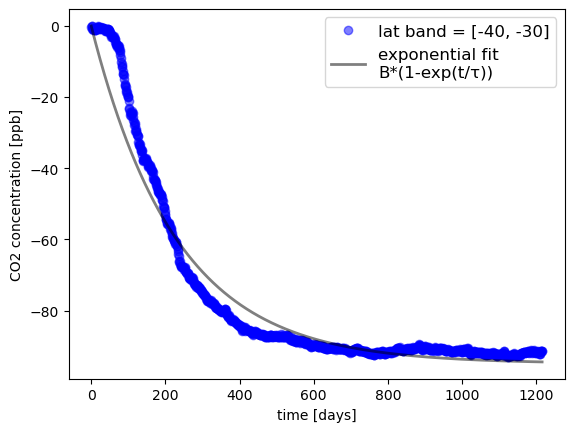

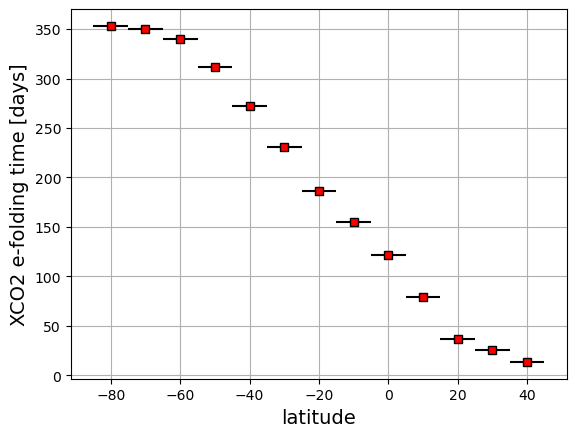

In [58]:
from scipy.optimize import curve_fit
import pdb

bin_width   = 10
maxlat      = 40
bin_edges   = np.arange(-90, maxlat+bin_width, bin_width)
bin_centers = np.cumsum(np.diff(bin_edges)) + bin_edges[0]
bin_widths  = np.diff(bin_edges)
tau         = np.zeros(len(bin_centers))

data = sibr_gpp_mf_res_X * 1e3

fig = plt.figure()
ax  = fig.add_subplot(111)
ax.set_ylabel('CO2 concentration [ppb]')
ax.set_xlabel('time [days]')

for i in range(len(bin_centers)):
    print(f'---- {i+1}/{len(bin_centers)} ----', end='\r')
    lats = slice(bin_edges[i], bin_edges[i+1])

    dd = horz_avg(data.sel(lat=lats))
    dd = dd.dropna('time')
    dd = dd.where(np.isfinite(dd), drop=True)
    tt = dd.time
    # seconds since first timestamp
    tt = (tt - tt[0]) / np.timedelta64(1, "D")
    
    def model(x, B, k):
        return B * (1 - np.exp(-k * x))

    popt, pcov = curve_fit(model, tt, dd, p0 = [0, 1/500])
    B, ki = popt

    if(i == 5):
        ax.plot(tt, dd, 'ob', alpha=0.5, label=f'lat band = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}]')
        ax.plot(tt, model(tt, B, ki), '-k', alpha=0.5, lw=2, label='exponential fit\nB*(1-exp(t/τ))')
        
    tau[i] = 1/ki
ax.legend(fontsize=12)
#plt.savefig('taufit_lat50-54.png', dpi=200)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.errorbar(bin_centers, tau, marker='s', color='k', markerfacecolor='r', xerr=bin_widths/2, linestyle='none')
ax.set_xlabel('latitude', fontsize=14)
ax.set_ylabel('XCO2 e-folding time [days]', fontsize=14)
ax.grid()
plt.savefig('sibr_gpp_tau_xco2.png', dpi=200)

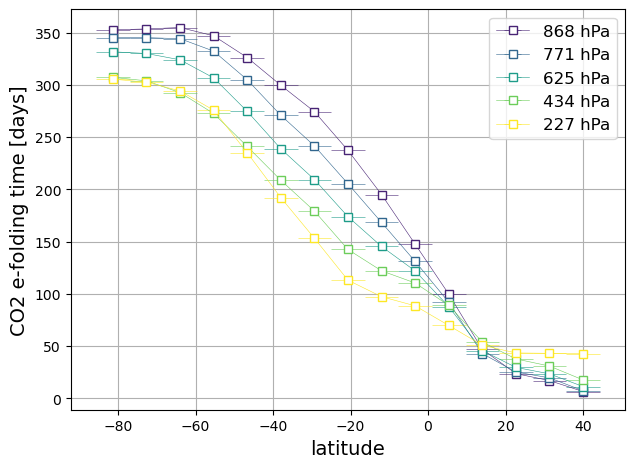

In [59]:
from scipy.optimize import curve_fit
import pdb

lat_bins    = 15
maxlat      = 40
bin_edges   = np.linspace(-90, maxlat, lat_bins+1)
bin_centers = np.cumsum(np.diff(bin_edges)) + bin_edges[0]
bin_widths  = np.diff(bin_edges)
tau         = np.zeros(lat_bins)
ppp = np.linspace(15, 35, 5).astype(int)
ppp = np.arange(10, 31, 5)

colors = plt.cm.viridis(np.linspace(0.1, 1, len(ppp)))

data = sibr_gpp_mf_res * 1e3

fig = plt.figure(figsize=(5.5*1.3, 4*1.3))
ax = fig.add_subplot(111)

for j in range(len(ppp)):

    for i in range(lat_bins):
        print(f'---- {i+1}/{lat_bins} ----', end='\r')
        lats = slice(bin_edges[i], bin_edges[i+1])

        dd = data.isel(lev = ppp[j])
        dd = horz_avg(dd.sel(lat=lats))
        dd = dd.dropna('time')
        dd = dd.where(np.isfinite(dd), drop=True)
        tt = dd.time
        # seconds since first timestamp
        tt = (tt - tt[0]) / np.timedelta64(1, "D")
        
        def model(x, B, k):
            return B * (1 - np.exp(-k * x))

        p0 = [0, 1/500]
        popt, pcov = curve_fit(model, tt, dd, p0=p0)
        B, ki = popt
        tau[i] = 1/ki
        
    ax.errorbar(bin_centers, tau, marker='s', color=colors[j], markerfacecolor='w', xerr=bin_widths/2, 
                linestyle='-', label=f'{inversion_tools.lev_to_p(ppp[j]):.0f} hPa', linewidth=0.4)
     
ax.set_xlabel('latitude', fontsize=14)
ax.set_ylabel('CO2 e-folding time [days]', fontsize=14)
ax.grid()
ax.legend(fontsize=12)
plt.savefig('sibr_gpp_tau_co2.png', dpi=200)